# 날씨 데이터 재도전 — 수집 가능성과 결합 정확성

**판정: 날씨 자체가 실패했다고 결론낼 수 없다. 기존 결합본은 검증된 모델 입력이 아니다.**
원본 100만 행과 기존 결합본을 전수 비교한다. 새 관측은 IEM의 2022-12-23,
ATL/JFK/ORD 하루치 **수집 시험**이며 비행 데이터의 연도를 검증한 것이 아니다.
모델 성능 실험·Teacher 학습은 하지 않는다. 원본 날짜/예측 시점 계약을 먼저 확정해야 한다.

재현: 저장소에서 `uv run --offline python -u notebooks/build_weather_review.py`.
필요 패키지: 프로젝트 의존성 + nbformat, nbclient, nbconvert, ipykernel.
실행 중 실제 데이터 두 파일을 읽으며 IEM 원본 캐시가 없을 때만 소량 다운로드한다.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/weather.py').exists())
sys.path.insert(0, str(ROOT / 'notebooks'))
from weather_feasibility import audit_existing, fetch_probe, check_alignment, OUT
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
meta, legacy = audit_existing()
display(pd.Series({k: meta[k] for k in ['raw_rows', 'legacy_columns', 'raw_columns_changed', 'origin_airports', 'origin_airports_with_weather', 'candidate_year_verified']}))
display(legacy.round(4))

raw_rows                        1000000
legacy_columns                       29
raw_columns_changed                  []
origin_airports                     374
origin_airports_with_weather         30
candidate_year_verified           False
dtype: object

,column,nonmissing,coverage_pct,labeled_coverage_pct
0,Weather_Origin_temp,557725,55.7725,55.1704
1,Weather_Origin_dwpt,557725,55.7725,55.1704
2,Weather_Origin_rhum,557725,55.7725,55.1704
3,Weather_Origin_prcp,515683,51.5683,51.0312
4,Weather_Origin_snow,0,0.0000,0.0000
5,Weather_Origin_wspd,557725,55.7725,55.1704
6,Weather_Origin_wpgt,0,0.0000,0.0000
7,Weather_Origin_pres,557725,55.7725,55.1704
8,Weather_Origin_coco,535580,53.5580,53.0598


## 기존 결합의 한계
원본 행/컬럼은 유지됐다. 그러나 출발지 374공항 중 30공항만 관측이 연결됐고,
실제 날씨 컬럼은 **9개**다(29열−원본19열의 나머지 1개는 Dep_Hour).
결합률은 숫자가 존재하는 비율이며 올바른 연도·시각이 연결됐다는 증거가 아니다.
snow/wpgt의 전량 결측은 이 파일의 사실이지, 모든 관측소가 해당 항목을 제공하지 않는다는 증거는 아니다.


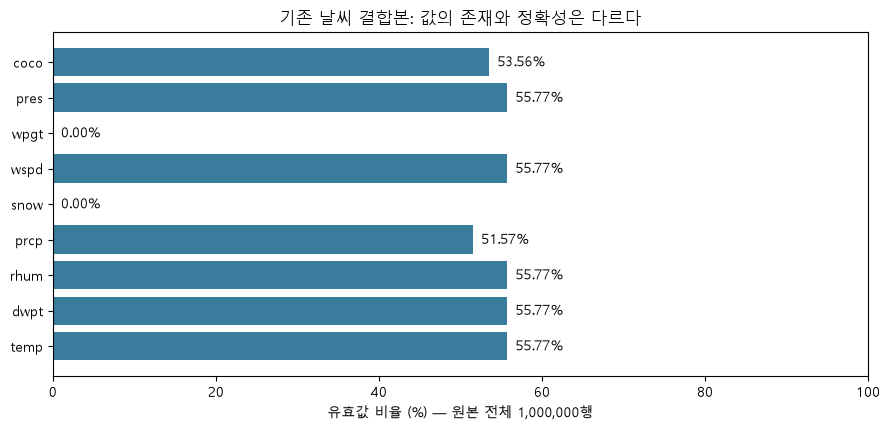

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(legacy.column.str.replace('Weather_Origin_', ''), legacy.coverage_pct, color='#397c9b')
ax.set(xlim=(0,100), xlabel='유효값 비율 (%) — 원본 전체 1,000,000행', title='기존 날씨 결합본: 값의 존재와 정확성은 다르다')
for i, value in enumerate(legacy.coverage_pct): ax.text(value + 1, i, f'{value:.2f}%', va='center')
fig.tight_layout(); fig.savefig(OUT / 'legacy_coverage.png', dpi=150); plt.show()

## 대체 자료 실제 수집
[IEM ASOS/METAR](https://mesonet.agron.iastate.edu/request/download.phtml)의
routine/special 보고, UTC, 미량 강수 T 보존. IEM은 여러 원천을 통합하며 품질관리가 제한적이다.
보고시각만으로 원래 이용 가능 시각을 확정할 수 없다.
변수 단위: 기온 °F, 풍속/돌풍 knot, 시정 mile, 구름고도 ft, 강수 inch.
gust 미보고를 0으로 대치하지 않는다. snowdepth(쌓인 눈 깊이)와 SN(눈 현상)은 다르다.


,station,reports,tmpf_reported,sknt_reported,gust_reported,vsby_reported,skyc1_reported,skyl1_reported,wxcodes_reported,p01i_reported,snowdepth_reported,metar_reported
0,ATL,27,27,27,21,27,27,27,6,27,0,27
1,JFK,39,39,39,36,39,39,39,27,39,0,39
2,ORD,36,36,36,36,36,36,36,33,36,4,36


,station,valid,gust,vsby,wxcodes,snowdepth
0,ORD,2022-12-23 00:23,28.0,1.75,-SN BR,NaN
1,JFK,2022-12-23 00:49,NaN,9.00,-RA,NaN
2,ORD,2022-12-23 00:51,26.0,1.25,-SN BR,NaN
3,JFK,2022-12-23 00:51,24.0,9.00,-RA,NaN
4,ATL,2022-12-23 00:52,NaN,3.00,NaN,NaN
5,ORD,2022-12-23 01:06,24.0,2.00,-SN BR,NaN
6,ORD,2022-12-23 01:39,26.0,2.00,-SN BR,NaN
7,ORD,2022-12-23 01:51,22.0,2.00,-SN BR,NaN


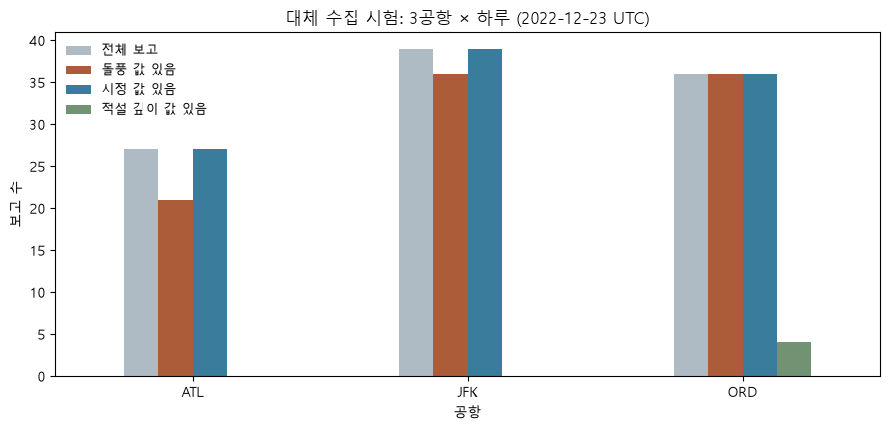

In [3]:
obs, coverage = fetch_probe()
display(coverage)
display(obs[['station','valid','gust','vsby','wxcodes','snowdepth']].head(8))
fig, ax = plt.subplots(figsize=(9,4.4))
plot = coverage.set_index('station')[['reports','gust_reported','vsby_reported','snowdepth_reported']]
plot.columns = ['전체 보고','돌풍 값 있음','시정 값 있음','적설 깊이 값 있음']
plot.plot.bar(ax=ax, color=['#aebbc5','#ad5c39','#397c9b','#719373'], rot=0)
ax.set(title='대체 수집 시험: 3공항 × 하루 (2022-12-23 UTC)', ylabel='보고 수', xlabel='공항')
ax.legend(frameon=False, fontsize=9); fig.tight_layout()
fig.savefig(OUT / 'iem_probe_coverage.png', dpi=150); plt.show()

## 시간 정렬 검사
아래 날짜/12시는 시간대 동작 예시이며 실제 항공편이 아니다. 겨울·여름 DST 차이를 확인한다.
모호하거나 존재하지 않는 DST 시각은 추측하지 않고 NaT 처리한다.
관측 102개에 대해 이용 가능 시각을 **관측+10분으로 가정한 시험**만 한다.
이 가정은 당시 전송 지연이나 사후 수정본의 가용성을 검증하지 않는다.
72개 공항·시각 요청 중 경계/자료간격 때문에 미매칭이 남아도 미래 관측으로 채우지 않는다.


In [4]:
timezone_examples, join_checks = check_alignment(obs)
display(timezone_examples)
display(pd.Series(join_checks))
assert meta['raw_columns_changed'] == []
assert join_checks['future_reports_selected'] == 0
assert join_checks['flight_rows_used'] == 0
print('실제 비행 데이터에 미검증 연도의 날씨를 병합하지 않았음.')

,local_date,hhmm,New_York_utc,Chicago_utc
0,2022-01-15,1200,2022-01-15 17:00:00+00:00,2022-01-15 18:00:00+00:00
1,2022-07-15,1200,2022-07-15 16:00:00+00:00,2022-07-15 17:00:00+00:00


requests                   72.0
matched                    68.0
assumed_latency_minutes    10.0
future_reports_selected     0.0
flight_rows_used            0.0
max_age_minutes            69.0
dtype: float64

실제 비행 데이터에 미검증 연도의 날씨를 병합하지 않았음.


## 다음 결정을 위한 근거
1. 연도는 미확정이다. 월별 20개, 총 240개 비행 지문을 `year_verification_fingerprints.csv`로 추출했다.
   BTS 원본의 복수 연도·월과 비교하되 결과/지연 필드는 대조·피처 생성에서 제외한다.
   단일 연도를 가정하지 말고 복수 후보·불일치·미확정을 행별 보존한다.
2. 현지 날짜를 확정한 뒤 공항별 IANA 시간대와 관측소 이력으로 UTC 변환한다.
3. 양 공항의 관측을 동일한 예측 기준시각에 결합한다. 도착시 실제 날씨는 사전 예측용으로 금지하고,
   당시 발행된 도착시간대 TAF가 있으면 별도 issue-time/valid-time 계약으로 사용한다.
4. 정렬 검증 후에만 동일 CV/피처셋의 날씨 없음·출발·양공항 비교를 진행한다.
5. 원본 대조가 불가능하면 사건별 날씨 결합을 보류한다. 월별 기후평년값은 별도 가설이며 대체 실측이 아니다.

상세 출처·판정·테스트 결과는 `output/weather_recovery_review.md`에 있다.
